In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4


In [2]:
core_path    = os.getcwd()
orbital_df = pd.read_pickle(os.path.join(core_path, 'data/lvl3/orbital_df.pkl'))

family_df     = orbital_df[orbital_df['is_family_member']].copy().reset_index(drop=True)
background_df = orbital_df[~orbital_df['is_family_member']].copy().reset_index(drop=True)

print(f"Family members : {len(family_df):,}")
print(f"Background     : {len(background_df):,}")
print(f"Total          : {len(orbital_df):,}")
print(f"Background %   : {100*len(background_df)/len(orbital_df):.1f}%")

Family members : 230,607
Background     : 807,634
Total          : 1,038,241
Background %   : 77.8%


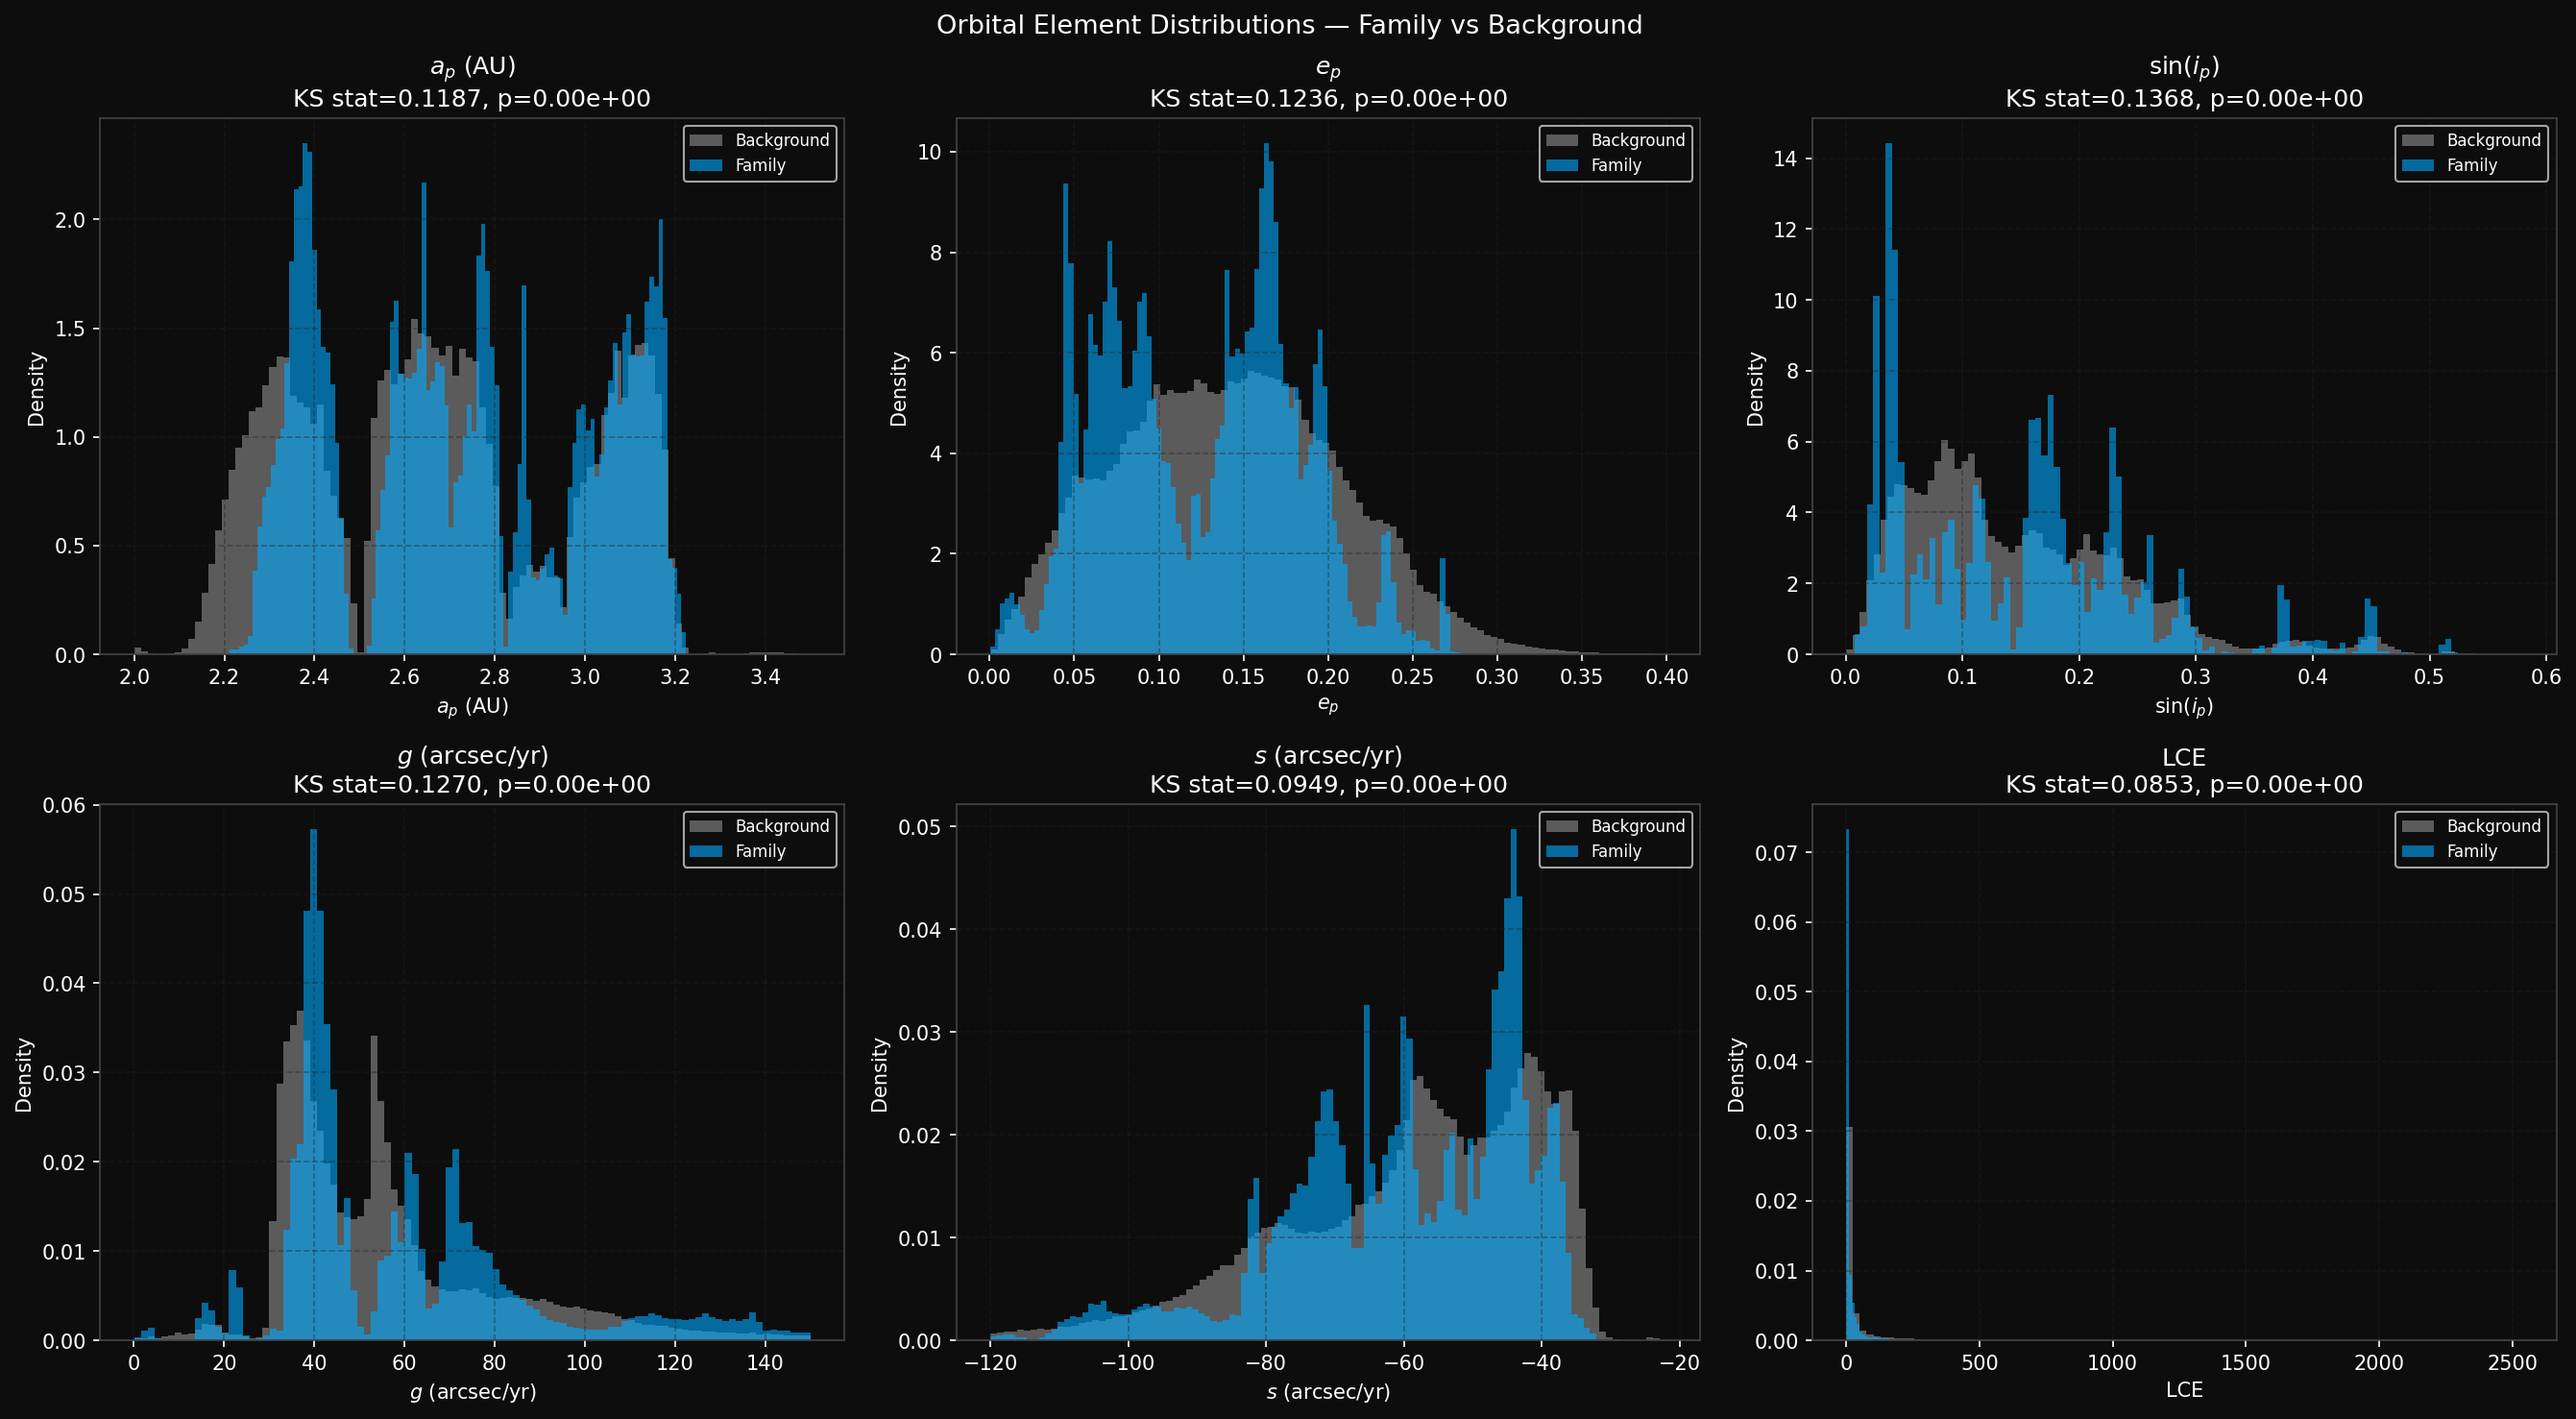

In [3]:
features  = ['a_p', 'e_p', 'sin_i_p', 'g', 's', 'LCE']
labels    = ['$a_p$ (AU)', '$e_p$', '$\\sin(i_p)$',
             '$g$ (arcsec/yr)', '$s$ (arcsec/yr)', 'LCE']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat, label in zip(axes.flatten(), features, labels):
    bg_vals  = background_df[feat].values
    fam_vals = family_df[feat].values

    # KS test
    ks_stat, ks_p = ks_2samp(bg_vals, fam_vals)

    ax.hist(bg_vals,  bins=100, density=True, alpha=0.5,
            color='#aaaaaa', label='Background', edgecolor='none')
    ax.hist(fam_vals, bins=100, density=True, alpha=0.6,
            color='#00aaff', label='Family', edgecolor='none')

    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'{label}\nKS stat={ks_stat:.4f}, p={ks_p:.2e}')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle('Orbital Element Distributions — Family vs Background', fontsize=13)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '06_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()

In [4]:
print(f"{'Feature':<15} {'Family mean':>14} {'BG mean':>14} {'KS stat':>10} {'p-value':>12} {'Significant':>12}")
print("-" * 80)

for feat, label in zip(features, labels):
    bg_vals  = background_df[feat].values
    fam_vals = family_df[feat].values
    ks_stat, ks_p = ks_2samp(bg_vals, fam_vals)
    significant = "✅ Yes" if ks_p < 0.05 else "❌ No"
    print(f"{feat:<15} {fam_vals.mean():>14.4f} {bg_vals.mean():>14.4f} "
          f"{ks_stat:>10.4f} {ks_p:>12.2e} {significant:>12}")

Feature            Family mean        BG mean    KS stat      p-value  Significant
--------------------------------------------------------------------------------
a_p                     2.7342         2.6732     0.1187     0.00e+00        ✅ Yes
e_p                     0.1249         0.1422     0.1236     0.00e+00        ✅ Yes
sin_i_p                 0.1490         0.1462     0.1368     0.00e+00        ✅ Yes
g                      59.5397        55.6641     0.1270     0.00e+00        ✅ Yes
s                     -60.0519       -58.7160     0.0949     0.00e+00        ✅ Yes
LCE                    13.0478        26.3749     0.0853     0.00e+00        ✅ Yes


Inner (2.0–2.5 AU)        total= 321,173 family=  63,107 (19.6%) bg= 258,066 (80.4%)
Middle (2.5–2.95 AU)      total= 438,531 family=  97,467 (22.2%) bg= 341,064 (77.8%)
Outer (2.95–3.5 AU)       total= 278,537 family=  70,033 (25.1%) bg= 208,504 (74.9%)


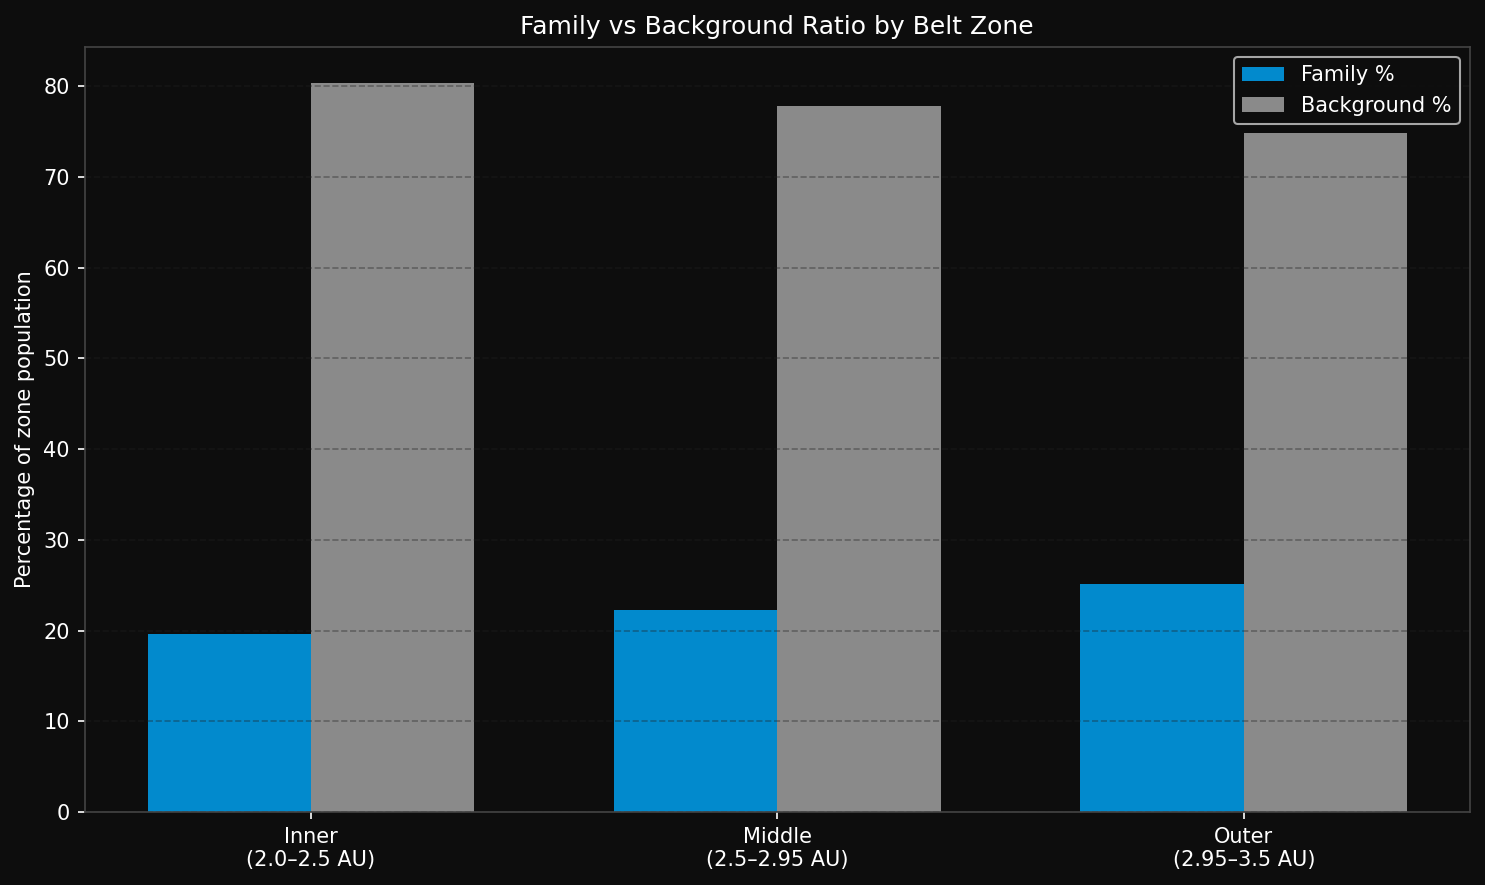

In [5]:
zones = {
    'Inner\n(2.0–2.5 AU)' : (2.0,  2.5),
    'Middle\n(2.5–2.95 AU)': (2.5,  2.95),
    'Outer\n(2.95–3.5 AU)' : (2.95, 3.5),
}

zone_stats = []
for zone_name, (a_min, a_max) in zones.items():
    zone_df  = orbital_df[(orbital_df['a_p'] >= a_min) & (orbital_df['a_p'] < a_max)]
    n_total  = len(zone_df)
    n_family = zone_df['is_family_member'].sum()
    n_bg     = n_total - n_family
    zone_stats.append({
        'zone':     zone_name,
        'total':    n_total,
        'family':   n_family,
        'background': n_bg,
        'fam_pct':  100 * n_family / n_total,
        'bg_pct':   100 * n_bg / n_total,
    })
    print(f"{zone_name.replace(chr(10),' '):<25} total={n_total:>8,} "
          f"family={n_family:>8,} ({100*n_family/n_total:.1f}%) "
          f"bg={n_bg:>8,} ({100*n_bg/n_total:.1f}%)")

zone_df_stats = pd.DataFrame(zone_stats)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(zone_stats))
w = 0.35

ax.bar(x - w/2, zone_df_stats['fam_pct'],  width=w,
       color='#00aaff', alpha=0.8, label='Family %')
ax.bar(x + w/2, zone_df_stats['bg_pct'],   width=w,
       color='#aaaaaa', alpha=0.8, label='Background %')

ax.set_xticks(x)
ax.set_xticklabels(zone_df_stats['zone'])
ax.set_ylabel('Percentage of zone population')
ax.set_title('Family vs Background Ratio by Belt Zone')
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '06_zone_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

In [6]:
from sklearn.neighbors import KDTree as skKDTree

# Build KDTree on family members
X_family = family_df[['a_p', 'e_p', 'sin_i_p']].values
X_bg     = background_df[['a_p', 'e_p', 'sin_i_p']].values

# Normalize before distance computation
from sklearn.preprocessing import RobustScaler
scaler   = RobustScaler()
X_fam_s  = scaler.fit_transform(X_family)
X_bg_s   = scaler.transform(X_bg)

print("Building KDTree on family members...")
tree = skKDTree(X_fam_s)

print("Querying nearest family member for each background asteroid...")
dist, _ = tree.query(X_bg_s, k=1)
dist     = dist.flatten()

background_df['dist_to_nearest_family'] = dist

print(f"\nDistance to nearest family member:")
print(f"  Mean   : {dist.mean():.4f}")
print(f"  Median : {np.median(dist):.4f}")
print(f"  <0.1   : {(dist < 0.1).sum():,}  ({100*(dist<0.1).mean():.1f}%) — very close")
print(f"  <0.2   : {(dist < 0.2).sum():,}  ({100*(dist<0.2).mean():.1f}%) — close")
print(f"  >0.5   : {(dist > 0.5).sum():,}  ({100*(dist>0.5).mean():.1f}%) — far")

Building KDTree on family members...
Querying nearest family member for each background asteroid...

Distance to nearest family member:
  Mean   : 0.1506
  Median : 0.1193
  <0.1   : 350,819  (43.4%) — very close
  <0.2   : 590,732  (73.1%) — close
  >0.5   : 19,387  (2.4%) — far


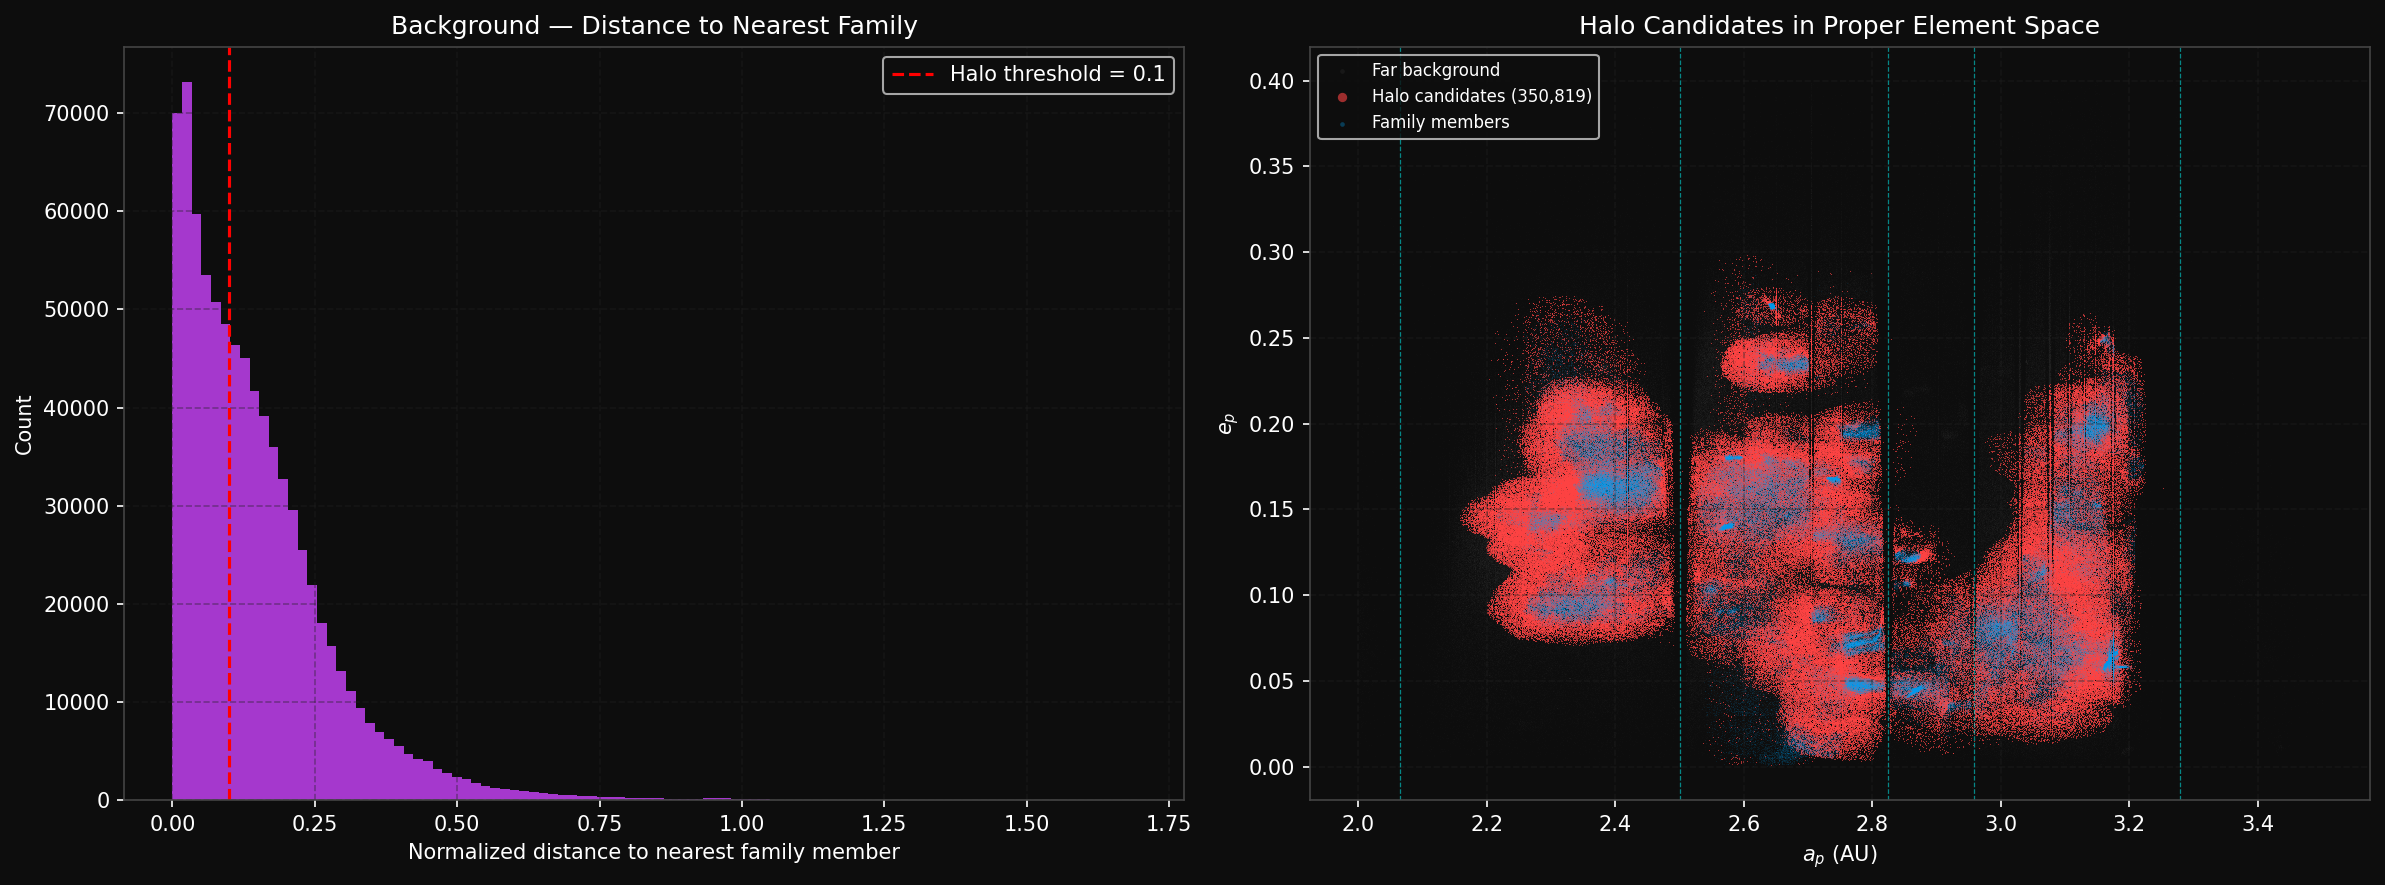


Halo candidates (dist < 0.1) : 350,819 (43.4% of background)


In [7]:
HALO_THRESHOLD = 0.1   # normalized distance — potential escaped members

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distance histogram
axes[0].hist(dist, bins=100, color='#cc44ff', edgecolor='none', alpha=0.8)
axes[0].axvline(HALO_THRESHOLD, color='red', linestyle='--',
                label=f'Halo threshold = {HALO_THRESHOLD}')
axes[0].set_xlabel('Normalized distance to nearest family member')
axes[0].set_ylabel('Count')
axes[0].set_title('Background — Distance to Nearest Family')
axes[0].legend()
axes[0].grid(True)

# Spatial map of halo candidates
halo_mask = dist < HALO_THRESHOLD
halo_df   = background_df[halo_mask]
far_df    = background_df[~halo_mask]

axes[1].scatter(far_df['a_p'],  far_df['e_p'],
                s=0.05, c='#333333', alpha=0.3,
                linewidths=0, label='Far background')
axes[1].scatter(halo_df['a_p'], halo_df['e_p'],
                s=0.2,  c='#ff4444', alpha=0.6,
                linewidths=0, label=f'Halo candidates ({halo_mask.sum():,})')
axes[1].scatter(family_df['a_p'], family_df['e_p'],
                s=0.05, c='#00aaff', alpha=0.3,
                linewidths=0, label='Family members')

resonances = {'4:1': 2.065, '3:1': 2.501, '5:2': 2.825, '7:3': 2.958, '2:1': 3.279}
for name, loc in resonances.items():
    axes[1].axvline(loc, color='cyan', linewidth=0.6, linestyle='--', alpha=0.5)

axes[1].set_xlabel('$a_p$ (AU)')
axes[1].set_ylabel('$e_p$')
axes[1].set_title('Halo Candidates in Proper Element Space')
axes[1].legend(markerscale=10, fontsize=8)
axes[1].grid(True)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '06_halo_candidates.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"\nHalo candidates (dist < {HALO_THRESHOLD}) : {halo_mask.sum():,} "
      f"({100*halo_mask.mean():.1f}% of background)")

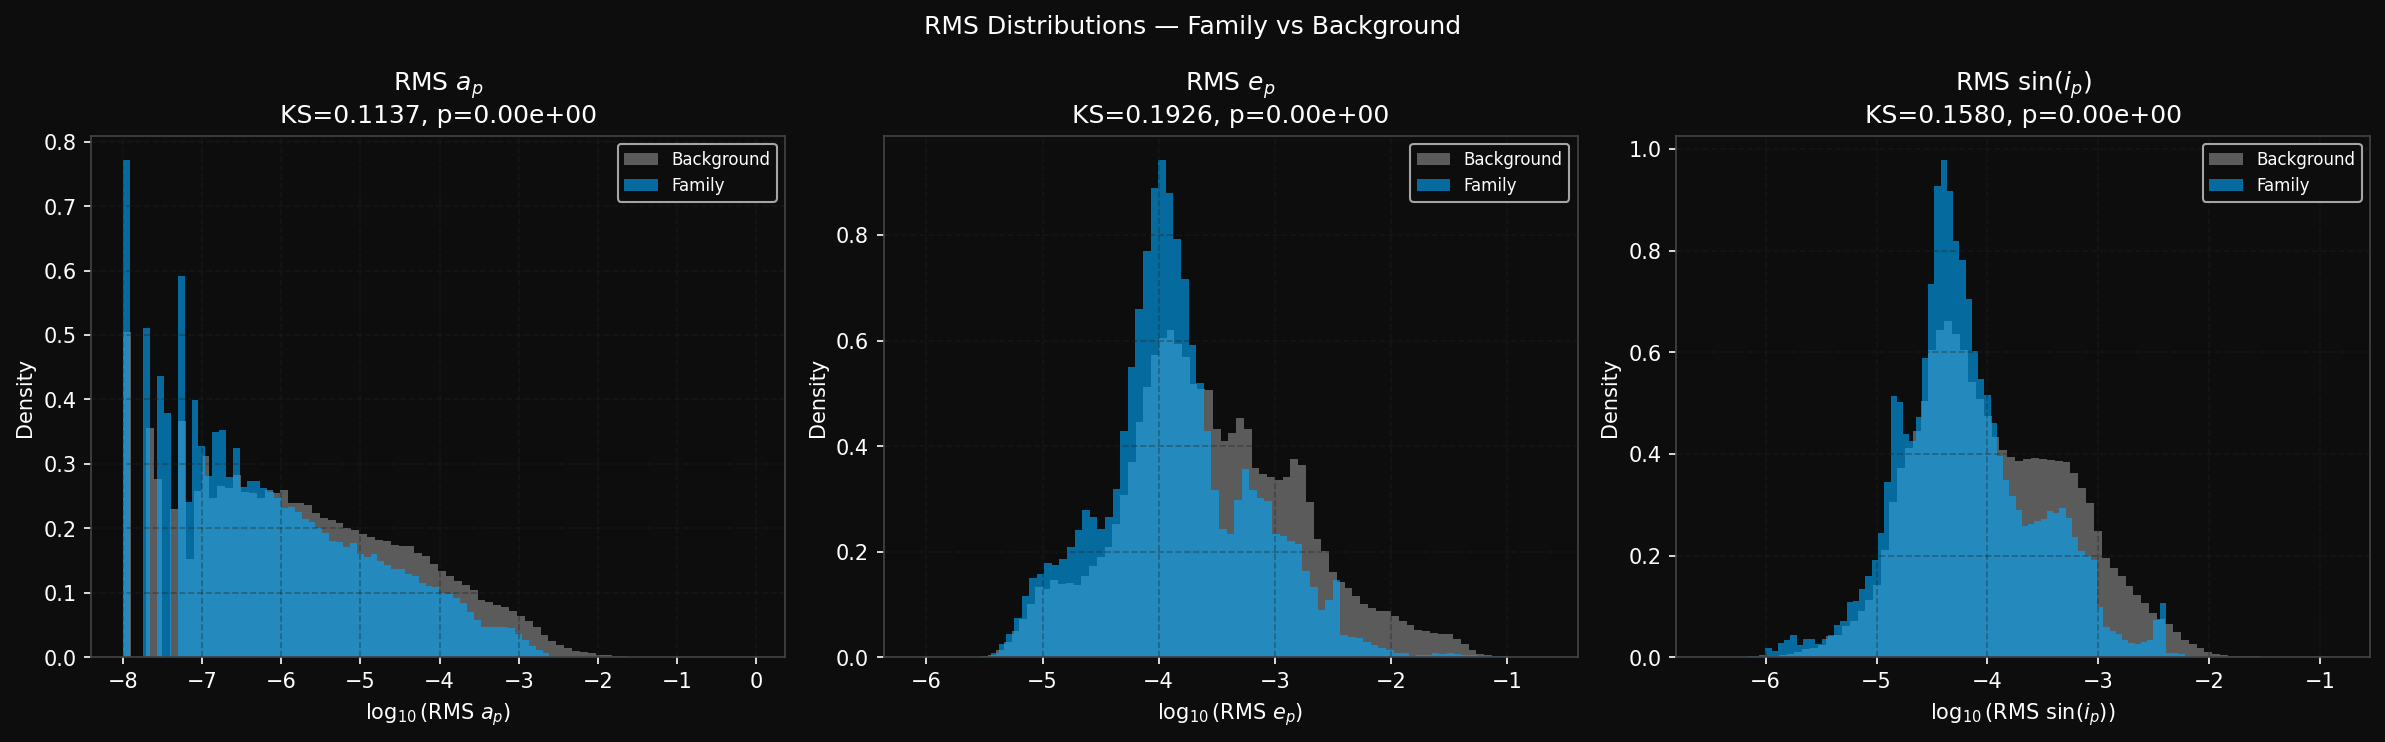

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, label in zip(axes,
    ['rms_a', 'rms_e', 'rms_sin_i'],
    ['RMS $a_p$', 'RMS $e_p$', 'RMS $\\sin(i_p)$']
):
    bg_vals  = np.log10(background_df[col].replace(0, np.nan).dropna())
    fam_vals = np.log10(family_df[col].replace(0, np.nan).dropna())

    ax.hist(bg_vals,  bins=80, density=True, alpha=0.5,
            color='#aaaaaa', label='Background', edgecolor='none')
    ax.hist(fam_vals, bins=80, density=True, alpha=0.6,
            color='#00aaff', label='Family', edgecolor='none')

    ks_stat, ks_p = ks_2samp(
        background_df[col].dropna(), family_df[col].dropna()
    )

    ax.set_xlabel(f'$\\log_{{10}}$({label})')
    ax.set_ylabel('Density')
    ax.set_title(f'{label}\nKS={ks_stat:.4f}, p={ks_p:.2e}')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle('RMS Distributions — Family vs Background', fontsize=12)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '06_rms_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

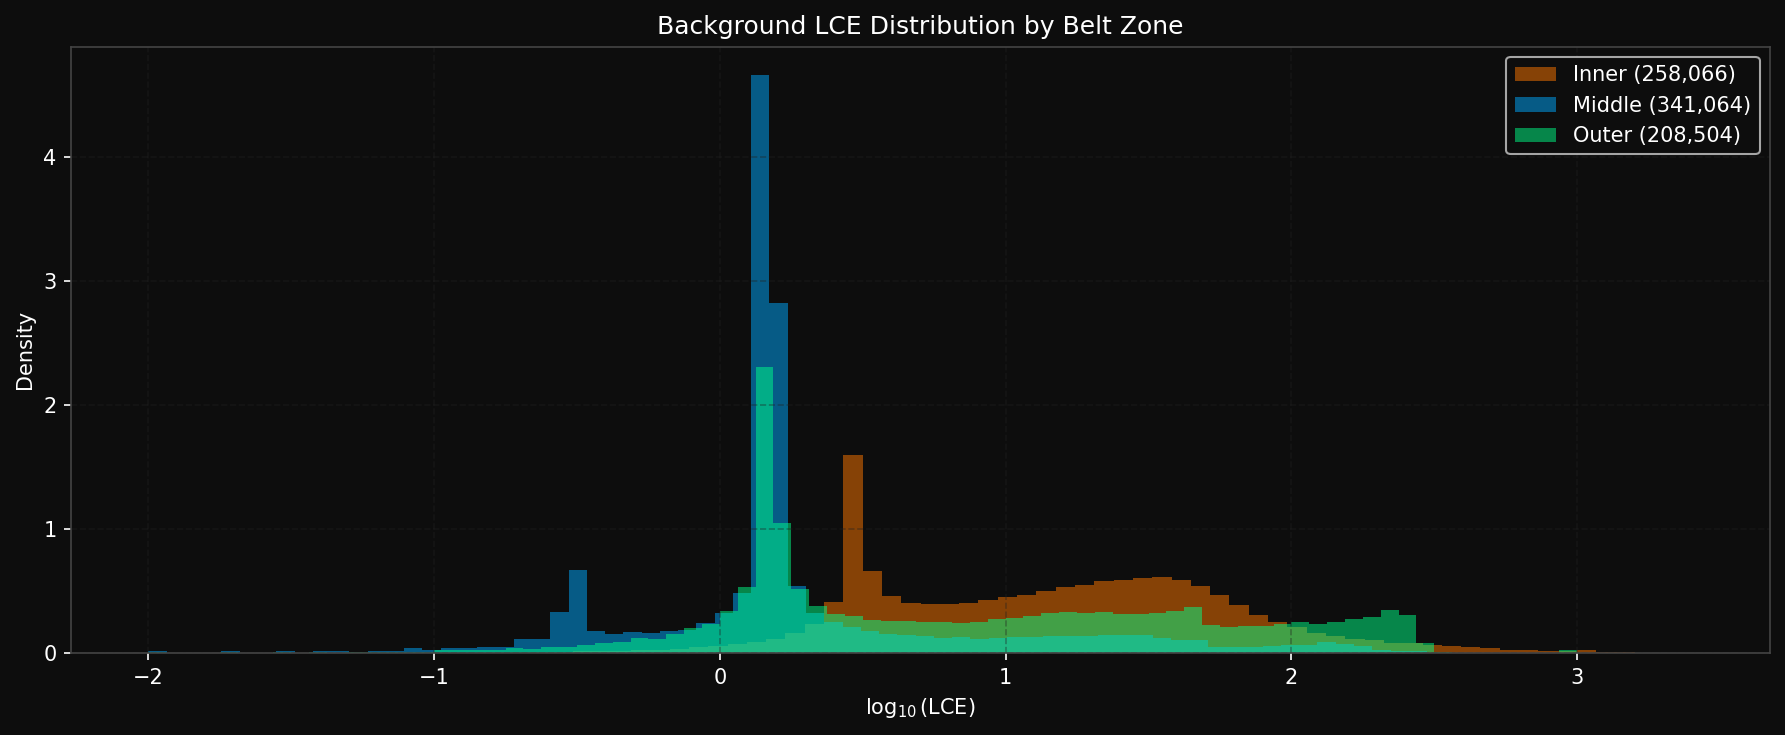

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

zone_colors = {'Inner': '#ff7700', 'Middle': '#00aaff', 'Outer': '#00ff88'}
zone_bounds = {'Inner': (2.0, 2.5), 'Middle': (2.5, 2.95), 'Outer': (2.95, 3.5)}

for zone_name, (a_min, a_max) in zone_bounds.items():
    zone_bg = background_df[
        (background_df['a_p'] >= a_min) &
        (background_df['a_p'] <  a_max)
    ]
    ax.hist(
        np.log10(zone_bg['LCE']),
        bins=80, density=True, alpha=0.5,
        color=zone_colors[zone_name],
        label=f'{zone_name} ({len(zone_bg):,})',
        edgecolor='none'
    )

ax.set_xlabel('$\\log_{10}$(LCE)')
ax.set_ylabel('Density')
ax.set_title('Background LCE Distribution by Belt Zone')
ax.legend()
ax.grid(True)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '06_bg_lce_zones.png'), dpi=200, bbox_inches='tight')
plt.show()

In [10]:
print("=== Background Population Summary ===\n")

print(f"Total background asteroids : {len(background_df):,}")
print(f"As % of full belt          : {100*len(background_df)/len(orbital_df):.1f}%")

print(f"\n--- Orbital Element Medians ---")
for feat, label in zip(['a_p', 'e_p', 'sin_i_p', 'g', 's'],
                       ['a_p', 'e_p', 'sin_i_p', 'g', 's']):
    bg_med  = background_df[feat].median()
    fam_med = family_df[feat].median()
    print(f"  {label:<12} BG={bg_med:.4f}  Family={fam_med:.4f}  "
          f"Δ={abs(bg_med-fam_med):.4f}")

print(f"\n--- Halo Analysis ---")
print(f"  Halo candidates (dist<0.1) : {halo_mask.sum():,} "
      f"({100*halo_mask.mean():.1f}% of background)")
print(f"  Likely primordial (dist>0.5): {(dist>0.5).sum():,} "
      f"({100*(dist>0.5).mean():.1f}% of background)")

print(f"\n--- Chaos (LCE) ---")
print(f"  Background median LCE : {background_df['LCE'].median():.3f}")
print(f"  Family median LCE     : {family_df['LCE'].median():.3f}")

=== Background Population Summary ===

Total background asteroids : 807,634
As % of full belt          : 77.8%

--- Orbital Element Medians ---
  a_p          BG=2.6543  Family=2.7220  Δ=0.0676
  e_p          BG=0.1410  Family=0.1318  Δ=0.0093
  sin_i_p      BG=0.1234  Family=0.1542  Δ=0.0309
  g            BG=50.3467  Family=48.3677  Δ=1.9790
  s            BG=-55.6636  Family=-58.7974  Δ=3.1337

--- Halo Analysis ---
  Halo candidates (dist<0.1) : 350,819 (43.4% of background)
  Likely primordial (dist>0.5): 19,387 (2.4% of background)

--- Chaos (LCE) ---
  Background median LCE : 2.990
  Family median LCE     : 1.970


In [12]:
background_df.to_pickle(
    os.path.join('data', 'results', 'classification_results', '08_background_analysis.pkl')
)

print(f"Saved → data/results/classification_results/08_background_analysis.pkl")

Saved → data/results/classification_results/08_background_analysis.pkl
